## __Partie 2 : Simulation__

### __Objectif__

Après avoir étudié le modèle analytique de Lotka-Volterra, qui fournit une vision globale des dynamiques des populations de proies et de prédateurs, nous proposons à présent une approche complémentaire par automate cellulaire. L'objectif principal de cette simulation est de représenter explicitement les interactions locales et les comportements individuels des agents (proies et prédateurs) dans un environnement spatial discret (une grille à deux dimensions).

Cette démarche nous permet d'observer comment les dynamiques globales du modèle émergent naturellement à partir de règles simples appliquées localement. En utilisant une simulation informatique interactive, nous pourrons visualiser directement l'évolution spatiale et temporelle des populations, ce qui facilite une meilleure compréhension intuitive du système étudié.

Par ailleurs, cette approche permet d'introduire des mécanismes plus réalistes comme la mobilité individuelle, la prédation sélective. Ces aspects sont difficiles à représenter de façon explicite dans des équations différentielles classiques de Lotka-Volterra. Ainsi, en comparant les résultats obtenus par cette simulation à ceux du modèle analytique (partie 1), puis à des données réelles (partie 3), nous pourrons évaluer de manière approfondie la pertinence et les limites de chacune de ces approches.



### __2.1. Environnement et règles du modèle__

Notre automate cellulaire se déroule sur une grille carrée bidimensionnelle, représentant un espace discret où chaque cellule peut être occupée par une proie, un prédateur ou rester vide. Les bords de la grille peuvent communiquer entre eux, ce qui signifie que les cellules situées sur les bords de la grille sont considérées comme adjacentes à celles de l'autre bord. Cela permet de simuler un environnement grand et continu, où les agents peuvent se déplacer librement sans limite artificielle.

Les règles locales régissant les interactions et comportements sont définies comme suit :

- Reproduction des proies: Une proie peut se reproduire dans une cellule voisine vide si au moins une autre proie est présente parmi ses huit cellules adjacentes. Ce processus dépend d'une probabilité définie par un paramètre spécifique (taux de reproduction des proies: `prey_reproduction_prob`).

- Déplacement des proies: Une proie peut se déplacer vers une cellule vide adjacente avec une probabilité donnée (mobilité des proies: `prey_moving_prob`).

- Reproduction des prédateurs: Un prédateur peut se reproduire si au moins un autre prédateur est présent dans son voisinage immédiat, selon une probabilité déterminée par le taux de reproduction des prédateurs: `predator_reproduction_prob`.

- Chasse: Les prédateurs chassent les proies situées dans les cellules adjacentes avec une probabilité de succès fixée (taux de chasse: `predator_hunting_prob`).

- Mort par famine: Un prédateur meurt après un nombre défini d'itérations sans réussir à capturer une proie (seuil de faim: `death_hunger`).

- Déplacement des prédateurs: Les prédateurs se déplacent vers la proie la plus proche si une telle proie est détectée dans leur voisinage. Sinon, leur déplacement reste limité à une cellule adjacente vide.

Ces règles simples, appliquées localement et simultanément à chaque cellule, permettent de simuler ainsi un écosystème proie-prédateur réaliste.

### __Implémentation informatique__
Pour implémenter l'automate cellulaire, nous avons opté pour Python, langage à la fois accessible et performant pour des simulations interactives. Afin d'assurer une visualisation en temps réel, nous utilisons la bibliothèque Pygame, permettant ainsi de suivre directement l'évolution spatiale des populations.

Le programme est structuré en plusieurs classes, chacune ayant une responsabilité précise : gestion des entités (proies et prédateurs), gestion locale des interactions cellulaires, contrôle global de la simulation, et rendu graphique. Nous utilisons également la bibliothèque Scipy (en particulier `cKDTree`) pour optimiser les calculs liés à la recherche rapide des proies les plus proches des prédateurs.

Les sous-sections suivantes détailleront précisément le rôle de chaque classe.

#### Installation des librairies nécessaires

In [1]:
%pip install numpy typing-extensions matplotlib pygame scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### __2.2. Définition des classes__
Afin de bien structurer notre code, nous allons définir plusieurs classes qui faciliteront la gestion de la simulation.
Voici les classes en question :
- `Prey` : qui représente une proie 
- `Predator` : qui représente un prédateur
- `CellState` : qui représente l'état d'une cellule (proie, prédateur ou vide)
- `Simulation` : qui représente la simulation

### __2.2.1. Classe Prey__
La classe `Prey` représente l'espèce __proie__ dans le cadre de notre simulation. Chaque objet de cette classe possède des caractéristiques biologiques simplifiées : une capacité à se reproduire, une aptitude au déplacement, et une position spatiale définie.


#### __Méthodes principales__
- `update(self, local_contents, local_empty_cells, **kwargs)` :  
  Méthode centrale qui simule un « tour de vie » de la proie. L'ordre des actions reflète une priorité biologique réaliste :  
  1. La proie tente d'abord de se reproduire si les conditions locales sont réunies.  
  2. En cas d’échec (absence de partenaire ou de cellule vide disponible), elle tente alors de se déplacer.  
  Cette hiérarchie met en évidence l'importance de la reproduction dans le cycle de vie des proies, tout en permettant une certaine mobilité pour explorer l'environnement.

- `reproduce(self, local_contents, local_empty_cells)` :  
  Cette méthode représente la tentative de reproduction d’une proie. Pour que la reproduction ait lieu, deux conditions doivent être réunies :
  - Présence d'au moins une proie voisine (mais sans surpopulation, comprise entre 1 à 3 autres proies voisines).
  - Disponibilité d’au moins une cellule vide adjacente.  
  Un tirage aléatoire basé sur `reproduction_prob` est effectué pour chaque proie voisine, et dès qu'il réussit, une nouvelle instance de `Prey` est créée dans une cellule voisine libre.

- `move(self, local_empty_cells)` :  
  Cette méthode modélise le déplacement d'une proie. Un déplacement n’est pas systématique: il dépend d'un tirage probabiliste déterminé par `moving_prob`. Si le déplacement est décidé, une cellule vide voisine est choisie aléatoirement et la proie actualise sa position. Ce mécanisme simple permet de simuler une mobilité naturelle tout en évitant une occupation trop régulière ou prévisible de l’espace.

### __2.2.2. Classe Predator__

La classe `Predator` modélise un **prédateur** dans notre simulation. Chaque objet représente un prédateur autonome capable de chasser, de se reproduire, de se déplacer, et de mourir s’il ne trouve pas de nourriture. Le comportement du prédateur repose sur des paramètres biologiques simplifiés qui dictent sa survie et son interaction avec les proies.

#### Méthodes principales :

- `update(nearest_prey, local_contents, local_empty_cells, **kwargs)` : méthode principale qui gère un __cycle de vie__ du prédateur.  
  L'ordre des priorités est le suivant :
  1. __Faim__ : le compteur `hunger` est incrémenté à chaque tour sans chasse réussie. 
  3. **Mort par faim** si le compteur `hunger` atteint le seuil `death_hunger`.
  4. **Chasse** : le prédateur tente de capturer une proie présente dans une cellule voisine.
  5. **Reproduction** si un congénère est présent et qu'une cellule vide est disponible.
  6. **Déplacement** vers la cellule vide la plus proche d'une proie, si aucune autre action n’a été effectuée.

- `hunt(local_contents)` : parcourt les cellules voisines à la recherche d’une proie (`Prey`). Si une proie est trouvée et que la tentative réussit (selon `hunting_prob`), elle est supprimée de la grille et le compteur de faim est réinitialisé.

- `reproduce(local_contents, local_empty_cells)` :
Cette méthode représente la tentative de reproduction d’un prédateur. Pour que la reproduction ait lieu, deux conditions doivent être réunies :
  - Présence d'au moins un prédateur voisin (mais sans surpopulation, fixée ici entre 1 et 4 autres prédateurs voisins).
  - Disponibilité d’au moins une cellule vide adjacente.  
Un tirage aléatoire basé sur `reproduction_prob` est effectué pour chaque prédateur voisin, et dès qu'il réussit, une nouvelle instance de `Predator` est créée dans une cellule voisine libre.

- `move(nearest_prey_pos, local_empty_cells)` : tente de déplacer le prédateur **vers la proie la plus proche**, en ne se déplaçant que d’une case à la fois. Le déplacement n’est effectué que si la cellule cible est vide.

Cette classe joue un rôle clé dans la dynamique proie-prédateur. Elle introduit une **pression écologique** sur les proies via la chasse, et permet de modéliser des phénomènes de **régulation naturelle** des populations. La gestion de la faim apporte une dimension réaliste de survie, renforçant la complexité et la cohérence de l’écosystème simulé.

### __2.2.3. Classe Cell__

La classe Cell correspond à un élément unitaire de la grille de la simulation.

Elle stocke les cellules voisines afin de pouvoir y accéder plus rapidement, sans avoir à les recalculer à chaque itération sur l’ensemble de la grille.
Elle contient également le contenu de la cellule (proie, prédateur ou rien) et met à jour le contenu de celle-ci.
Il n'est pas utile de commenter cette classe ou de justifier quelconque choix, car aucun choix n'a été fait, cette classe étant une simple structure de données.

### __2.2.4. Classe Simulation__
La classe Simulation s'occupe de mettre à jour toutes les cellules vides et de calculer également la position de la proie la plus proche de chaque prédateur.

Avant tout la simulation, initialise la grille avec des cellules et le nombre de proies et prédateurs initiaux.

La classe Simulation s'occupe également de l'affichage de la simulation avec Pygame.

La fonction `get_nearest_prey` a été générée par IA. Cette partie est assez complexe algorithmiquement et requiert d'être optimisée avec une librairie comme `scipy` pour éviter de faire des calculs trop longs. Cette fonction permet de trouver la proie la plus proche d'un prédateur de manière efficace et vectorisée.
Elle utilise la structure de données `cKDTree` de la bibliothèque `scipy.spatial` pour effectuer des recherches de voisinage efficaces dans un espace à plusieurs dimensions.
Cette structure permet de diviser l'espace en cellules et d'organiser les points (ici, les positions des proies) sous forme d'un arbre. Après la construction de l'arbre, la recherche de la proie la plus proche d'une position donnée (la position d'un prédateur) est effectuée en parcourant l'arbre.
La complexité de la recherche est $O(n \log n)$, où $n$ est le nombre de points dans l'espace. En cherchant dans les listes directement, la complexité serait de $O(n^2)$. L'efficacité de cette méthode est particulièrement bénéfique lorsque le nombre de proies est élevé, car elle réduit considérablement le temps de calcul qui doit être effectué à chaque itération de la simulation.

## __2.3. Lancement de la simulation__

### __2.3.1. Simulation sans rendu__
Nous allons à présent lancer la simulation. Pour cela, nous devons formuler des hypothèses et choisir les différentes valeurs des paramètres de la simulation.

#### Hypothèses et paramètres

Premièrement, nous pouvons remarquer que nous sommes placés dans le cas où l'environnement est limité, tout comme dans la partie "Croissance logistique des proies" du modèle de Lotka-Volterra.  
Nous allons donc choisir un environnement de 1000x1000 cellules, ce qui nous permet d'avoir un nombre de cellules suffisantes pour que la simulation soit réaliste.

Nous choisissons également de placer 1000 proies et 1000 prédateurs à l'instant initial, afin que la simulation puisse bien se lancer, autrement, les proies et prédateurs mourraient trop rapidement.

Comme nous allons choisir différentes valeurs pour les paramètres de la simulation, nous allons ici justifier leur ordre de grandeur en général.

De prime abord, on choisit les paramètres de sorte que la simulation soit stable, c'est-à-dire que les proies et prédateurs ne meurent pas totalement, mais qu'ils ne se reproduisent pas trop rapidement non plus.
Nous allons choisir une probabilité de reproduction pas trop élevée pour éviter que les proies ne se reproduisent trop rapidement, car sinon tous les prédateurs les mangeraient, et mourraient ensuite à leur tour (puisqu'ils n'auraient plus de proies à manger).  
Concernant la reproduction des prédateurs, nous effectuons le même raisonnement.  
Pour le compte à rebours de la faim, nous allons choisir un nombre de tours assez élevé pour que les prédateurs ne meurent pas trop rapidement puisque les proies ne se reproduisent pas trop rapidement. Ce paramètre est surtout relié à la reproduction des proies et des prédateurs, donc il est important de le choisir en fonction de celui-ci.  
Nous allons choisir une valeur de déplacement des proies assez élevée pour que les proies se déplacent assez vite car sinon elles seraient trop statiques et la simulation ne serait pas stable.  
Enfin, pour la chasse, nous allons choisir une valeur relativement faible pour que les prédateurs ne mangent pas trop de proies, de nouveau pour maintenir la stabilité de la simulation.

Il est à noter que ces paramètres sont choisis et adaptés en fonction des uns et des autres. Nous allons donc choisir des valeurs qui nous semblent raisonnables, et nous les ferons varier par la suite pour voir l'impact de ces variations sur la simulation.






In [ ]:
import matplotlib.pyplot as plt
import pygame
from simulation import Simulation

import IPython

# Fixe le traceback du KeyboardInterupt
def custom_exc(shell, etype, evalue, tb, tb_offset=None):
    if etype == KeyboardInterrupt:
        print("Simulation interrompue par l'utilisateur.")
    else:
        shell.showtraceback((etype, evalue, tb), tb_offset=tb_offset)


ip = IPython.get_ipython()
if ip is not None:
    ip.set_custom_exc((KeyboardInterrupt,), custom_exc)

width = 100
height = 100
prey_reproduction_prob = 0.3
prey_moving_prob = 0.7
predator_hunting_prob = 0.3
predator_reproduction_prob = 0.25
predator_max_hunger = 15

nb_prey_init = 1000
nb_predator_init = 1000
pixel_size = 3


def run_simulation(render=False):
    pygame.init()

    nb_preys = []
    nb_predators = []
    if render:
        screen = pygame.display.set_mode((width * pixel_size, height * pixel_size))

    simulation = Simulation(width, height, prey_reproduction_prob, prey_moving_prob, predator_hunting_prob,
                            predator_reproduction_prob, predator_max_hunger, nb_prey_init, nb_predator_init, pixel_size)

    def update_simulation(render):
        simulation.update()
        if render:
            simulation.render_grid(screen)

    try:
        running = True
        clock = pygame.time.Clock()
        while running:
            for event in pygame.event.get():
                if event.type == pygame.QUIT:
                    running = False

            update_simulation(render)

            nb_preys.append(simulation.nb_prey)
            nb_predators.append(simulation.nb_predator)
            if simulation.nb_prey == 0 or simulation.nb_predator == 0:
                raise RuntimeError()
            if render:
                pygame.display.flip()
            clock.tick(60)  # Cap at 60 FPS
    except Exception as e:
        if isinstance(e, KeyboardInterrupt):
            print("Simulation interrupted by user.")
        elif isinstance(e, RuntimeError):
            print("Simulation terminée, plus de prédateur ou de proie")
        else:
            print(e)
            import traceback
            traceback.print_exc()
    finally:
        plt.plot(nb_preys, label="Proies")
        plt.plot(nb_predators, label="Predateurs")
        plt.title("Nombre de proies et de prédateurs au cours du temps")
        plt.xlabel("Temps")
        plt.ylabel("Nombre d'individus")
        plt.legend()
        plt.show()

        plt.plot(nb_preys, nb_predators)
        plt.title("Diagramme de phase")
        plt.xlabel("Nombre de proies")
        plt.ylabel("Nombre de prédateurs")
        plt.show()
        pygame.quit()

pygame 2.6.1 (SDL 2.28.4, Python 3.11.11)
Hello from the pygame community. https://www.pygame.org/contribute.html


### __Test de la simulation pour différentes valeurs de paramètres__
Nous allons à présent tester la simulation pour différentes valeurs des paramètres.  
Il est à noter que parfois, la simulation ne démarre pas, car les proies ou prédateurs meurent trop rapidement ; on doit la relancer plusieurs fois afin de trouver de meilleurs paramètres qui sont plus propices à un équilibre.
Enfin, nous nous contenterons ici uniquement de commenter les résultats de la simulation, puisque nous allons les comparer par la suite avec la réalité et le modèle de Lotka-Volterra.

#### __Simulation 1__
Nous commençons par tester la simulation avec certaines valeurs des paramètres pour avoir un premier aperçu de celle-ci.  

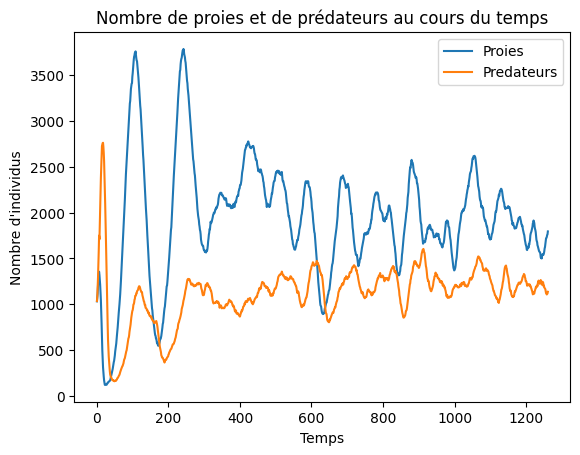

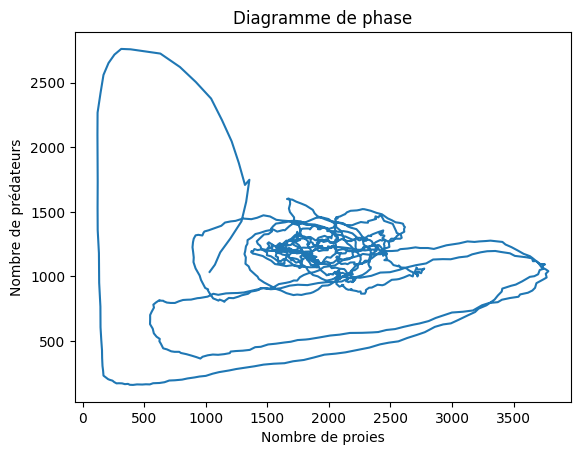

Simulation interrompue par l'utilisateur.


In [2]:
prey_reproduction_prob = 0.3
prey_moving_prob = 0.7
predator_hunting_prob = 0.3
predator_reproduction_prob = 0.25
predator_max_hunger = 15
width = 100
height = 100
run_simulation()

On observe que la simulation démarre bien, qu'elle atteint d'abord un point extrême proche de (0,0), puis commence à osciller et à se stabiliser autour de (2000,1000), bien que cela ne soit pas fixe.

#### __Simulation 2__

**/!\ Les paramètres de la simulation sont très contraignants, il faut parfois relancer la simulation beaucoup de fois avant d'en trouver une qui démarre bien.**

Par rapport à la simulation précédente nous allons réduire la probabilité de chasse des prédateurs ainsi que la probabilité de reproduction des prédateurs.

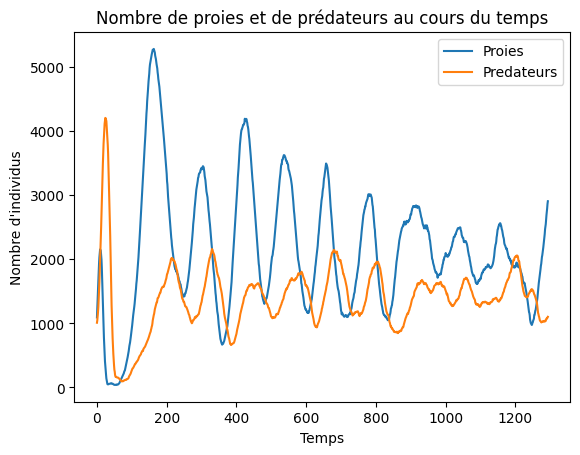

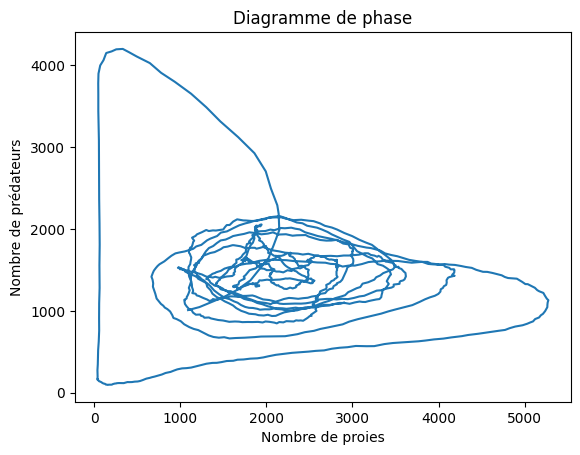

Simulation interrompue par l'utilisateur.


In [42]:
prey_reproduction_prob = 0.3
prey_moving_prob = 0.7
predator_hunting_prob = 0.2
predator_reproduction_prob = 0.2
predator_max_hunger = 23
width = 100
height = 100
run_simulation()

Comme attendu, après stabilisation, la population de proies est plus importante dans cette simulation que dans la simulation précédente. En effet, la probabilité de reproduction des prédateurs est plus faible et la probabilité de chasse est également plus faible ce qui laisse vivre plus de proies.

#### __Simulation 3__
Maintenant nous allons faire l'inverse de la simulation précédente en augmentant la probabilité de chasse des prédateurs et en augmentant également la probabilité de reproduction des prédateurs.

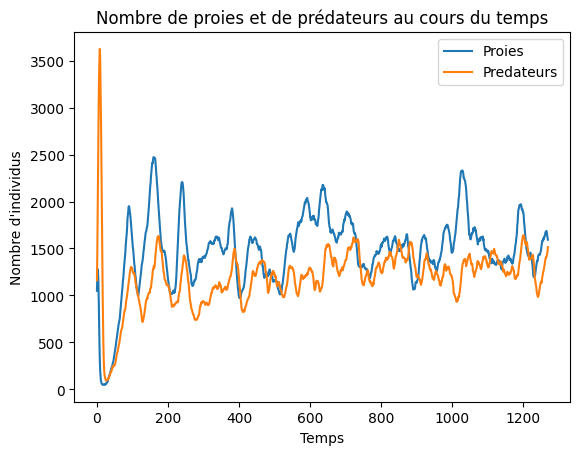

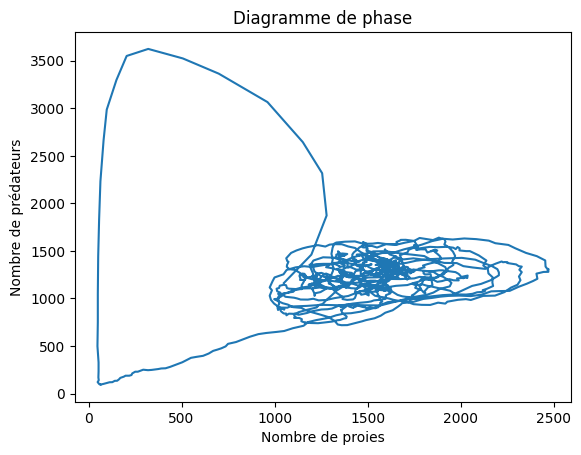

Simulation interrompue par l'utilisateur.


In [43]:
prey_reproduction_prob = 0.9
prey_moving_prob = 0.7
predator_hunting_prob = 0.8
predator_reproduction_prob = 0.6
predator_max_hunger = 10
width = 100
height = 100
run_simulation()

Après stabilisation, on remarque que la population de proies est plus faible que dans les simulations précédentes.
La population de prédateurs est maintenant du même ordre de grandeur que la population de proies mais est tout de même inférieure.
La population est restée stable dans les 3 précédentes simulations.

#### __Simulation 4__
Maintenant essayons d'augmenter le nombre de prédateurs moyen dans l'environnement. Pour cela nous allons augmenter la résistance des prédateurs à la famine. En effet, si les prédateurs meurent moins vite, ils auront plus de temps pour chasser les proies et donc la population de prédateurs va augmenter.

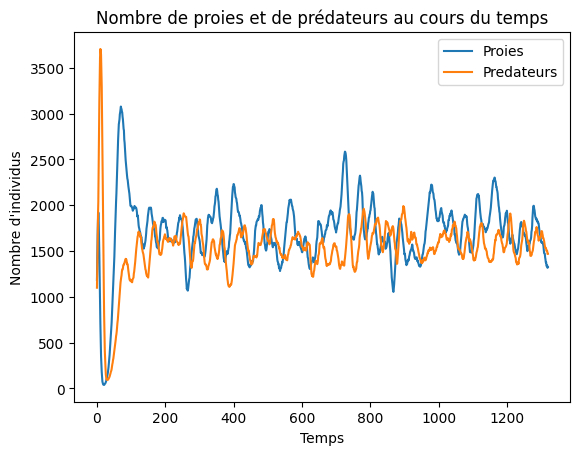

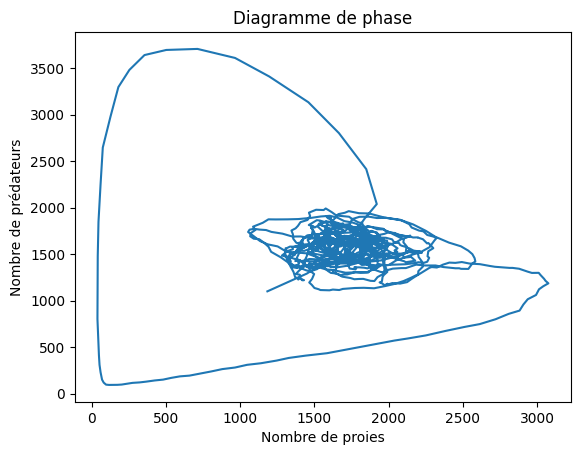

Simulation interrompue par l'utilisateur.


In [44]:
prey_reproduction_prob = 0.9
prey_moving_prob = 0.7
predator_hunting_prob = 0.55
predator_reproduction_prob = 0.45
predator_max_hunger = 30
width = 100
height = 100
run_simulation()

Après stabilisation, on remarque que la population de prédateurs est plus importante que dans les simulations précédentes et est également (parfois) légèrement supérieure à la population de proies.

#### __Simulation 5__
Nous allons maintenant essayer de diminuer la probabilité de reproduction des proies, augmenter le taux de chasse des prédateurs et réduire beaucoup le compteur de faim des prédateurs.

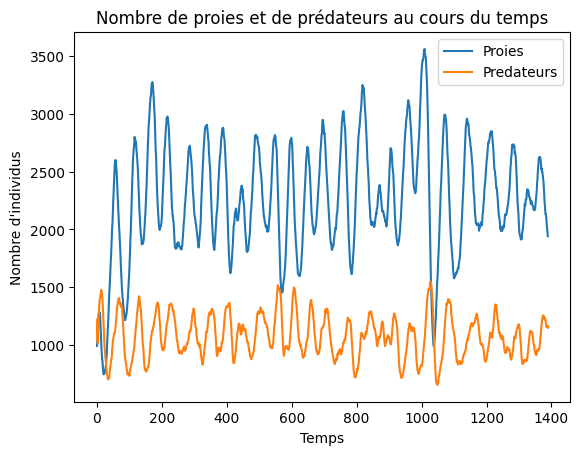

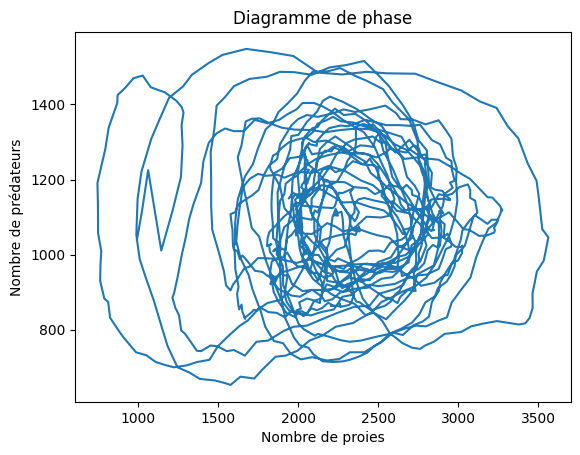

Simulation interrompue par l'utilisateur.


In [ ]:
prey_reproduction_prob = 0.4
prey_moving_prob = 0.7
predator_hunting_prob = 0.5
predator_reproduction_prob = 0.25
predator_max_hunger = 8
width = 100
height = 100
run_simulation()

Nous remarquons ici que la population des proies est tout le temps supérieure à la population des prédateurs. On observe également un diagramme de phase un peu plus circulaire que dans les simulations précédentes : il y a beaucoup plus de fluctuations par rapport aux autres simulations.

On remarque que dans l'ensemble des simulations (sauf la 5e), les simulations commencent dans une phase de stabilisation, avec une forte croissance de la population des prédateurs (donc d'une forte décroissance de la population des proies), puis d'une forte décroissance de la population des prédateurs (donc d'une forte croissance de la population des proies), puis d'une stabilisation autour d'un certain point. Cette phase d'initialisation est le résultat de l'organisation des populations à petite échelle (étant donné que la simulation commence avec un placement aléatoire des proies et prédateurs).
On remarque sur le rendu que les prédateurs suivent de très proche les proies, et les prédateurs les plus éloignés finissent par mourrir. On observe des "vagues" sur la grille (mouvement proie/prédateur).

### **2.3.2. Simulation visuelle**

Il est possible de visualiser la simulation en temps réel grâce à Pygame.

Pour cela, il suffit d'exécuter dans un terminal dans le dossier courant le fichier `simulation.py` avec la commande suivante :
```bash
python simulation.py
```

Il est possible de changer les paramètres de la simulation en modifiant les variables à la fin du fichier `simulation.py`.

### __2.4. Discussion des problèmes rencontrés__

#### __2.4.1. Problèmes de performance__

Le code de la simulation est assez lourd à exécuter. En effet, mettre à jour une grille de cellule de 100x100 c'est-à-dire 10 000 cellules, est déjà assez difficile à faire en moins de 1/30 s pour avoir une simulation fluide en temps réel.
C'est pourquoi nous avons choisi de minimiser le nombre calculs à effectuer pour chaque cellule à chaque itération.

Nous avons donc fait en sorte que les cellules gardent en mémoire leurs cellules voisines afin de ne pas avoir à les recalculer à chaque itération ce qui permet de gagner beaucoup de temps.

De plus le calcul de la proie la plus proche d'un prédateur est algorithmiquement complexe, c'est pourquoi nous avons utilisé la librairie `scipy` qui permet de le faire de manière efficace et vectorisée.

Nous avons réfléchi à d'autres manières de faire la simulation comme avec des tableaux numpy uniquement. Le code aurait été beaucoup moins lisible, mais plus efficace (car vectorisé). Cependant, nous avons choisi de garder le code lisible et compréhensible. On aurait pu également utiliser un autre langage de programmation plus bas niveau comme rust pour avoir un code compilé et donc exécuté plus rapidement. Néanmoins, nous avons choisi de rester sur Python pour la simplicité et la lisibilité du code et pour ne pas sortir du cadre de ce cours.

